In [105]:
import pickle
from Fullcontext_main import get_all_company_year_reports

all_companyYearReports = get_all_company_year_reports()

with open('all_companyYearReports.pkl', 'wb') as file:
    # 3. Use pickle.dump() to write the object to the file
    pickle.dump(all_companyYearReports, file)
    print(f"all_companyYearReports.pkl aktualisiert.")


Now collecting documents: AirFrance 2020
Retrieved 1 documents for AirFrance 2020
Now collecting documents: AirFrance 2021
Retrieved 1 documents for AirFrance 2021
Now collecting documents: AirFrance 2022
Retrieved 1 documents for AirFrance 2022
Now collecting documents: AirFrance 2023


KeyboardInterrupt: 

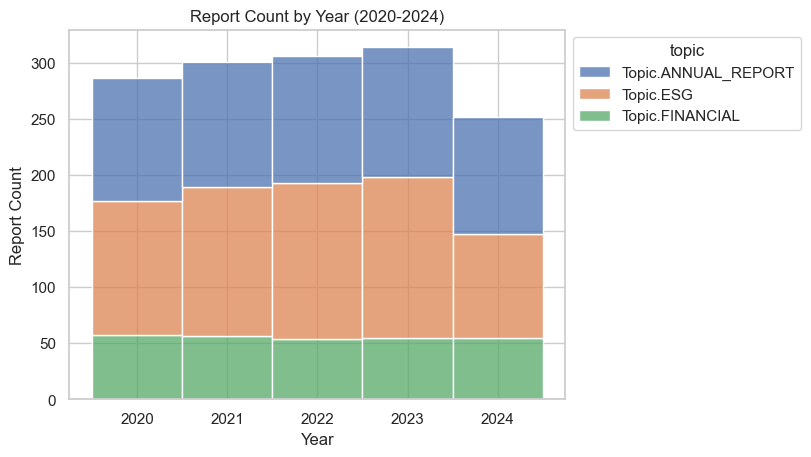

In [106]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

with open('all_companyYearReports.pkl', 'rb') as f:
    # Load the object from the file
    all_companyYearReports = pickle.load(f)

df_all_reports = pd.DataFrame([vars(record) for record in all_companyYearReports])
df_all_reports['period'] = pd.to_numeric(df_all_reports['period'])

#print(all_companyYearReports)
#fig, ax = plt.subplots(figsize=(10, 6))  # e.g., 10 inches wide, 6 inches tall

# Plot the distribution of clarity ratings, conditional on carat
ax = sns.histplot(
    data=df_all_reports,
    x='period',
    hue='topic',
    multiple='stack',
    discrete=True
)

sns.move_legend(
    ax,
    "upper left",        # Pin the "upper left" corner of the legend...
    bbox_to_anchor=(1, 1)  # ...to the "upper right" (1, 1) of the plot
)

plt.xlabel('Year')
plt.ylabel('Report Count')
plt.title('Report Count by Year (2020-2024)')

#plt.tight_layout()
plt.show()

In [119]:
esg_2020 = len(df_all_reports.query('period == 2023 and topic == "ESG"'))
print(esg_2020)

143


In [75]:
df_all_reports.sample(10)

companies = df_all_reports['company_name'].unique()
industries = df_all_reports['industry'].unique()
years = df_all_reports['period'].unique()

multi_index = pd.MultiIndex.from_product(
    [industries, years],
    names=['industry', 'year']
)
df_reports_counter = pd.DataFrame(index=multi_index).reset_index()
df_reports_counter['esg_and_annual'] = 0
df_reports_counter['esg_only'] = 0
df_reports_counter['annual_only'] = 0
df_reports_counter['nothing'] = 0

for company in companies:
    industry = df_all_reports[df_all_reports['company_name'] == company].iloc[0]['industry']
    for year in years:
        company_rows = df_all_reports.query(f"company_name == '{company}' and period == {year}")
        find_target_row_condition = (df_reports_counter['industry'] == industry) & (df_reports_counter['year'] == year)

        covered_topics = company_rows['topic'].unique()

        if "ESG" in covered_topics and "Annual Report" in covered_topics:
            df_reports_counter.loc[find_target_row_condition, 'esg_and_annual'] += 1
        elif "ESG" in covered_topics:
            df_reports_counter.loc[find_target_row_condition, 'esg_only'] += 1
        elif "Annual Report" in covered_topics:
            df_reports_counter.loc[find_target_row_condition, 'annual_only'] += 1
        else:
            df_reports_counter.loc[find_target_row_condition, 'nothing'] += 1

df_reports_counter_grouped = df_reports_counter.groupby(by='year')[['esg_and_annual', 'esg_only', 'annual_only', 'nothing']].sum()
df_reports_counter_grouped.head(20)


,esg_and_annual,esg_only,annual_only,nothing
year,,,,
2020,73,43,35,16
2021,79,46,31,11
2022,78,52,33,4
2023,83,49,31,4
2024,53,30,50,34


In [80]:
df_reports_counter_grouped.reset_index(inplace=True)
df_long = df_reports_counter_grouped.melt(
    id_vars=['year'],                 # Column(s) to keep as identifiers
    value_vars=['esg_and_annual', 'esg_only', 'annual_only', 'nothing'], # Columns to unpivot
    var_name='report_kind',                  # Name for the new "variable" column
    value_name='counter'                   # Name for the new "value" column
)

df_long.head(20)

,year,report_kind,counter
0,2020,esg_and_annual,73
1,2021,esg_and_annual,79
2,2022,esg_and_annual,78
3,2023,esg_and_annual,83
4,2024,esg_and_annual,53
5,2020,esg_only,43
6,2021,esg_only,46
7,2022,esg_only,52
8,2023,esg_only,49
9,2024,esg_only,30


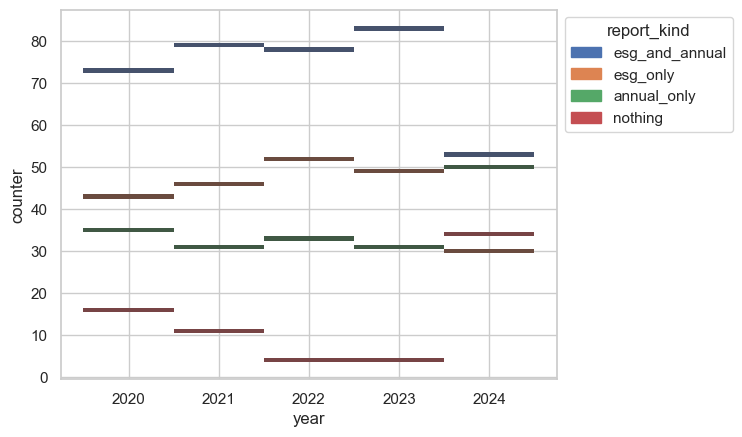

In [91]:
ax = sns.histplot(
    data=df_long,
    x='year',
    y='counter',
    hue='report_kind',
    multiple='fill',
    discrete=True
)

sns.move_legend(
    ax,
    "upper left",        # Pin the "upper left" corner of the legend...
    bbox_to_anchor=(1, 1)  # ...to the "upper right" (1, 1) of the plot
)
#plt.tight_layout()
plt.show()

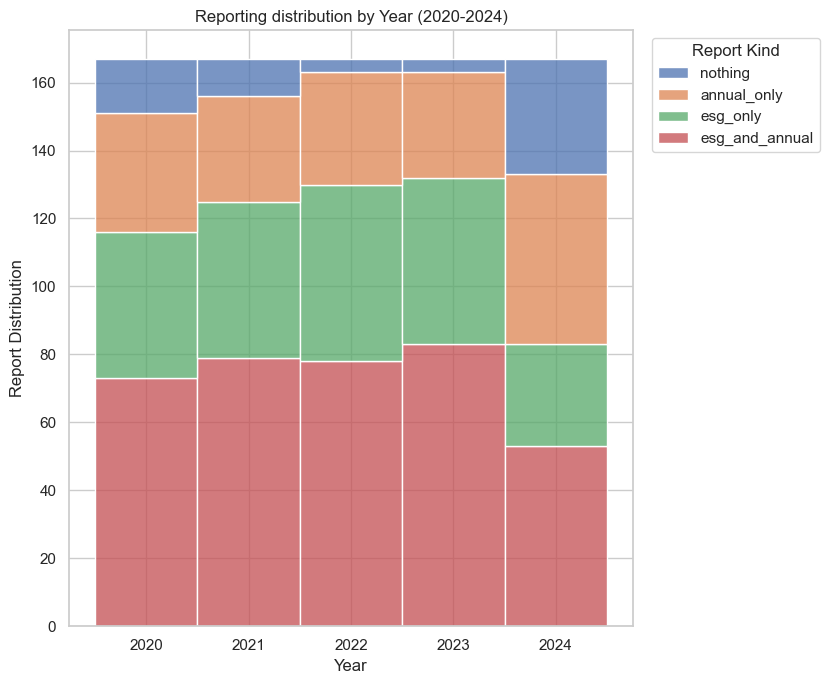

In [102]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load and clean data (same as steps 1 from above)
df_cleaned = df_long
df_cleaned = df_cleaned[['year', 'report_kind', 'counter']]

# Define the stack order
stack_order = ['nothing', 'annual_only', 'esg_only', 'esg_and_annual']

# Create the plot
plt.figure(figsize=(10, 7))
sns.histplot(
    df_cleaned,
    x='year',
    weights='counter',      # Use 'Count' for the bar height
    hue='report_kind',     # Color by 'ReportKind'
    multiple='stack',     # Stack the bars
    hue_order=stack_order,
    discrete=True# Use our custom order
)

# Customize and save
plt.xlabel('Year')
plt.ylabel('Report Distribution')
plt.title('Reporting distribution by Year (2020-2024)')
plt.xticks(sorted(df_cleaned['year'].unique())) # Ensure all year ticks are shown
sns.move_legend(plt.gca(), "upper left", bbox_to_anchor=(1.02, 1), title='Report Kind')
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig('report_kind_stacked_bar_seaborn.png')

In [125]:
from GroundTruth import loadSheet
import mysql.connector

mydb = mysql.connector.connect(
  host="localhost",
  user="root",
  password="MyN3wP4ssw0rd",
  database="democratizeesg"
)

mycursor = mydb.cursor()


industry_agnostic_indicators_sheet = loadSheet("1QoOHmD0nxb52BIVpKyniVdYej1W5o1-sNot7DpaBl2w", "IndustryAgnostricIndicators!A1:L")
industry_agnostic_units_to_convert = industry_agnostic_indicators_sheet[industry_agnostic_indicators_sheet['isUnitConversion'] == "TRUE"]
industry_agnostic_units_to_convert = industry_agnostic_units_to_convert[['IndicatorID', 'isOutcomeEffect']]

industry_specific_indicators_sheet = loadSheet("1QoOHmD0nxb52BIVpKyniVdYej1W5o1-sNot7DpaBl2w", "IndustrySpecificIndicators!A1:L")
industry_specific_indicators_sheet = industry_specific_indicators_sheet[industry_specific_indicators_sheet['isUnitConversion'] == "TRUE"]
industry_specific_indicators_sheet = industry_specific_indicators_sheet[['IndicatorID', 'isOutcomeEffect']]

units_to_convert = pd.concat([industry_agnostic_units_to_convert, industry_specific_indicators_sheet])

#print(units_to_convert)


sql_query = "SELECT year, indicator_id, not_disclosed FROM democratizeesg.big_dataset_consolidated;"
mycursor.execute(sql_query)
results = mycursor.fetchall()

columns = [col[0] for col in mycursor.description]
df_all_rows = pd.DataFrame(results, columns=columns)
#print(df_all_rows.head())

merged_df = pd.merge(df_all_rows, units_to_convert, left_on='indicator_id', right_on='IndicatorID', how='inner')
merged_df.drop(columns=['IndicatorID'], inplace=True)
merged_df.head(20)



,year,indicator_id,not_disclosed,isOutcomeEffect
0,2020,carbon_credits_offsets,1,TRUE
1,2020,deadweight_tonnage,1,FALSE
2,2020,energy_consumed,0,TRUE
3,2020,energy_consumed_heavy_fuel,0,TRUE
4,2020,energy_consumed_renewable,0,TRUE
5,2020,energy_produced,1,FALSE
6,2020,environmental_ex,1,FALSE
7,2020,fuel_consumed,0,TRUE
8,2020,fuel_consumed_fossil,0,TRUE
9,2020,fuel_consumed_renewable,0,TRUE


year             928
indicator_id     928
not_disclosed    928
IndicatorType    928
dtype: int64


C:\Users\yotim\AppData\Local\Temp\ipykernel_8568\4289620887.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged_disclosed['IndicatorType'] = df_merged_disclosed['IndicatorType'].replace('FALSE', 'Processes & Policies')
C:\Users\yotim\AppData\Local\Temp\ipykernel_8568\4289620887.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged_disclosed['IndicatorType'] = df_merged_disclosed['IndicatorType'].replace('TRUE', 'Outcome & Impact')


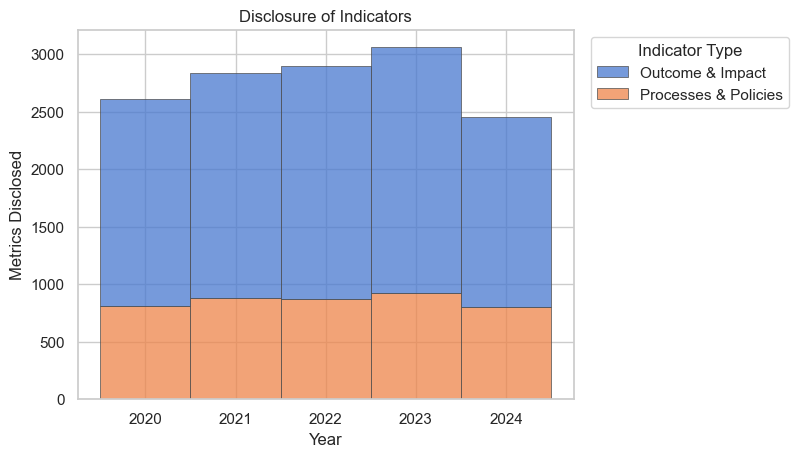

In [147]:
df_merged_disclosed = merged_df.loc[merged_df['not_disclosed'] == 0]
#df_merged_disclosed.rename(columns = {'isOutcomeEffect':'IndicatorType'}, inplace=True)
df_merged_disclosed['IndicatorType'] = df_merged_disclosed['IndicatorType'].replace('FALSE', 'Processes & Policies')
df_merged_disclosed['IndicatorType'] = df_merged_disclosed['IndicatorType'].replace('TRUE', 'Outcome & Impact')

print(df_merged_disclosed.query('IndicatorType == "Processes & Policies" and year == 2023').count())

sns.histplot(
    df_merged_disclosed,
    x="year",
    hue="IndicatorType",
    multiple="stack",
    palette="muted",
    edgecolor=".3",
    linewidth=.5,
    discrete=True
)
plt.xlabel('Year')
plt.ylabel('Metrics Disclosed')
plt.title('Disclosure of Indicators')
sns.move_legend(plt.gca(), "upper left", bbox_to_anchor=(1.02, 1), title='Indicator Type')
